# Notebook 4/4 — Evaluation + Compression + Thesis Outputs
**Requires:** All 3 checkpoints from Notebooks 1–3 to be on Drive  
**Time:** ~40 min on free T4  

## Before running
1. Runtime → Change runtime type → **T4 GPU**
2. Run Cell 1 (install) → restart runtime
3. Run all remaining cells top to bottom
4. When done, you can close this tab — the checkpoint is saved to Drive


**Sections:**
| # | Content | Time |
|---|---------|------|
| A | Verify checkpoints exist | 1 min |
| B | Ensemble evaluation + results table | 5 min |
| C | Confusion matrices + ROC curves | 3 min |
| D | Grad-CAM (all 3 models) | 12 min |
| E | Training curves | 2 min |
| F | Quantization (INT8) | 8 min |
| G | Pruning (20% + 40%) | 5 min |
| H | Knowledge distillation | 12 min |
| I | Efficiency table | 3 min |
| J | OASIS-1+2 baseline comparison | 1 min |


In [1]:
import warnings; warnings.filterwarnings('ignore')
!pip install "numpy<2.0.0" "scipy<1.13.0" "scikit-learn<1.5.0" \
             "pandas==2.2.2" nibabel matplotlib pillow torchinfo --quiet
print("✓ Done. Restart runtime now.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.8/37.8 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 49.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires scipy>=1.13, but y

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
print('✓ Drive mounted')


Mounted at /content/drive
✓ Drive mounted


In [3]:
import warnings; warnings.filterwarnings('ignore')
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision.models as models
import numpy as np, pandas as pd, json, time, os
from pathlib import Path
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import f1_score, balanced_accuracy_score
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import nibabel as nib
from PIL import Image
import torchvision.transforms as T

# ── Paths ────────────────────────────────────────────────────────────────
BASE   = Path('/content/drive/MyDrive/alzheimer_thesis')
O3_DIR = BASE / 'data' / 'oasis3_raw'
CKPT   = BASE / 'checkpoints'
LOGS   = BASE / 'logs'
MANI   = BASE / 'data' / 'manifests'
GRAD   = BASE / 'gradcam'
COMP   = BASE / 'compression'
for d in [CKPT, LOGS, MANI, GRAD, COMP]:
    d.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = 224; NUM_CLASSES = 3
print(f'Device: {DEVICE}')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE"}')


Device: cuda
GPU: Tesla T4


In [4]:
def extract_25d(nifti_path, size=IMG_SIZE):
    vol = nib.load(str(nifti_path)).get_fdata().astype(np.float32)
    if vol.ndim == 4: vol = vol[...,0]
    z, mid = vol.shape[2], vol.shape[2]//2
    slices = []
    for off in [-1,0,1]:
        idx = int(np.clip(mid+off, 0, z-1))
        sl  = vol[:,:,idx]
        sl  = np.array(Image.fromarray(sl).resize((size,size), Image.BILINEAR))
        sl  = (sl - sl.mean()) / (sl.std() + 1e-8)
        slices.append(sl.astype(np.float32))
    return np.stack(slices, axis=0)


In [5]:
class OASIS3Dataset(Dataset):
    def __init__(self, csv_path, augment=False):
        self.df = pd.read_csv(csv_path)
        self.aug = T.Compose([
            T.RandomHorizontalFlip(p=0.5),
            T.RandomRotation(degrees=15),
            T.RandomAffine(degrees=0, translate=(0.08,0.08), scale=(0.9,1.1)),
            T.GaussianBlur(kernel_size=3, sigma=(0.1,1.0)),
        ]) if augment else None
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        t = torch.from_numpy(extract_25d(row['path']))
        if self.aug: t = self.aug(t)
        return t, int(row['label'])

def make_sampler(df):
    counts = df['label'].value_counts().sort_index().values
    w = 1.0/counts
    return WeightedRandomSampler([w[int(l)] for l in df['label']], len(df), replacement=True)

BATCH = 16
train_df = pd.read_csv(MANI/'train.csv')
train_loader = DataLoader(OASIS3Dataset(MANI/'train.csv', augment=True), batch_size=BATCH,
                          sampler=make_sampler(train_df), num_workers=2, pin_memory=True)
val_loader   = DataLoader(OASIS3Dataset(MANI/'val.csv'),  batch_size=BATCH,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(OASIS3Dataset(MANI/'test.csv'), batch_size=BATCH,
                          shuffle=False, num_workers=2, pin_memory=True)
x, y = next(iter(train_loader))
print(f'Data OK: batch {tuple(x.shape)}, range [{x.min():.2f},{x.max():.2f}]')


Data OK: batch (16, 3, 224, 224), range [-1.06,4.74]


In [6]:
# ── EfficientNet-B0 ──────────────────────────────────────────────────────
def build_efficientnet():
    m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    m.classifier = nn.Sequential(nn.Dropout(0.5), nn.Linear(m.classifier[1].in_features,128),
                                  nn.ReLU(), nn.Dropout(0.4), nn.Linear(128, NUM_CLASSES))
    for p in m.features.parameters(): p.requires_grad = False
    return m

# ── MobileNetV3-Small ────────────────────────────────────────────────────
def build_mobilenet():
    m = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    in_f = m.classifier[3].in_features
    m.classifier[3] = nn.Sequential(nn.Linear(in_f,64), nn.ReLU(), nn.Dropout(0.4),
                                     nn.Linear(64, NUM_CLASSES))
    for p in m.features.parameters(): p.requires_grad = False
    return m

# ── LightAlzNet ──────────────────────────────────────────────────────────
class SEBlock(nn.Module):
    def __init__(self,ch,r=16):
        super().__init__()
        self.se=nn.Sequential(nn.AdaptiveAvgPool2d(1),nn.Flatten(),
            nn.Linear(ch,max(ch//r,4),bias=False),nn.ReLU(),
            nn.Linear(max(ch//r,4),ch,bias=False),nn.Sigmoid())
    def forward(self,x): return x*self.se(x).view(x.size(0),-1,1,1)

class DWSConvBlock(nn.Module):
    def __init__(self,in_ch,out_ch,stride=1):
        super().__init__()
        self.block=nn.Sequential(
            nn.Conv2d(in_ch,in_ch,3,stride=stride,padding=1,groups=in_ch,bias=False),
            nn.BatchNorm2d(in_ch),nn.ReLU6(inplace=True),
            nn.Conv2d(in_ch,out_ch,1,bias=False),nn.BatchNorm2d(out_ch),nn.ReLU6(inplace=True))
        self.se=SEBlock(out_ch)
        self.skip=(nn.Conv2d(in_ch,out_ch,1,stride=stride,bias=False)
                   if (in_ch!=out_ch or stride!=1) else nn.Identity())
    def forward(self,x): return self.se(self.block(x))+self.skip(x)

class LightAlzNet(nn.Module):
    def __init__(self,num_classes=3):
        super().__init__()
        self.stem=nn.Sequential(nn.Conv2d(3,32,3,stride=2,padding=1,bias=False),
                                  nn.BatchNorm2d(32),nn.ReLU6(inplace=True))
        self.body=nn.Sequential(DWSConvBlock(32,64,2),DWSConvBlock(64,128,2),
            DWSConvBlock(128,128,1),DWSConvBlock(128,256,2),
            DWSConvBlock(256,256,1),DWSConvBlock(256,512,2))
        self.head=nn.Sequential(nn.AdaptiveAvgPool2d(1),nn.Flatten(),
                                  nn.Linear(512,256),nn.ReLU(),nn.Dropout(0.5),
                                  nn.Linear(256,num_classes))
    def forward(self,x): return self.head(self.body(self.stem(x)))


---
## A — Verify Checkpoints

In [7]:
# Must show ✓ for all 3 before continuing
missing = []
for name in ['efficientnet','mobilenet','lightalznet']:
    p = CKPT / f'{name}_best.pth'
    if p.exists():
        ck = torch.load(p, map_location='cpu', weights_only=False)
        print(f'  ✓ {name:<22} best val F1={ck["best_f1"]:.4f}  epoch={ck["epoch"]}')
    else:
        print(f'  ✗ {name} — MISSING. Run Notebook {["1","2","3"][["efficientnet","mobilenet","lightalznet"].index(name)]} first.')
        missing.append(name)
if missing:
    print(f'\n⚠ Cannot continue — missing: {missing}')
else:
    print('\n✓ All checkpoints present — proceed')


  ✓ efficientnet           best val F1=0.4023  epoch=31
  ✓ mobilenet              best val F1=0.4591  epoch=33
  ✓ lightalznet            best val F1=0.5056  epoch=49

✓ All checkpoints present — proceed


---
## B — Ensemble Evaluation

In [8]:
from sklearn.metrics import classification_report, balanced_accuracy_score, roc_auc_score

def load_best(model, name):
    ck = torch.load(CKPT/f'{name}_best.pth', map_location=DEVICE, weights_only=False)
    model.load_state_dict(ck['model']); model.to(DEVICE).eval()
    print(f'  ✓ {name:<22} val F1={ck["best_f1"]:.4f}')
    return model

def get_probs(model, loader):
    model.eval(); ap,al=[],[]
    with torch.no_grad():
        for x,y in loader:
            p=torch.softmax(model(x.to(DEVICE)),dim=1)
            ap.extend(p.cpu().numpy()); al.extend(y.numpy())
    return np.array(ap), np.array(al)

print('Loading checkpoints...')
models_dict = {
    'EfficientNet-B0':   load_best(build_efficientnet(),'efficientnet'),
    'MobileNetV3-Small': load_best(build_mobilenet(),   'mobilenet'),
    'LightAlzNet':       load_best(LightAlzNet(),       'lightalznet'),
}

CLASS_NAMES=['CN','MCI','AD']; all_results={}; probs_list=[]; labels=None

for name,model in models_dict.items():
    probs,labels=get_probs(model,test_loader); probs_list.append(probs)
    preds=probs.argmax(1)
    try:    auc=roc_auc_score(labels,probs,multi_class='ovr',average='macro')
    except: auc=float('nan')
    params=sum(p.numel() for p in model.parameters())/1e6
    all_results[name]={'acc':float((preds==labels).mean()),
        'macro_f1':float(f1_score(labels,preds,average='macro',zero_division=0)),
        'bal_acc':float(balanced_accuracy_score(labels,preds)),
        'auc':float(auc),'params_M':float(params)}

ens_probs=np.mean(probs_list,axis=0); ens_preds=ens_probs.argmax(1)
try:    ens_auc=float(roc_auc_score(labels,ens_probs,multi_class='ovr',average='macro'))
except: ens_auc=float('nan')
all_results['Ensemble']={'acc':float((ens_preds==labels).mean()),
    'macro_f1':float(f1_score(labels,ens_preds,average='macro',zero_division=0)),
    'bal_acc':float(balanced_accuracy_score(labels,ens_preds)),
    'auc':float(ens_auc),'params_M':0.0}

print('\n'+'='*76)
print('TEST SET RESULTS — copy into thesis Chapter 4')
print('='*76)
print(f'{"Model":<26} {"Acc":>7} {"Macro-F1":>9} {"Bal-Acc":>9} {"AUC-ROC":>9} {"Params":>8}')
print('-'*76)
for name,r in all_results.items():
    p=f'{r["params_M"]:.2f}M' if r['params_M']>0 else 'ensemble'
    print(f'{name:<26} {r["acc"]:>7.4f} {r["macro_f1"]:>9.4f} {r["bal_acc"]:>9.4f} {r["auc"]:>9.4f} {p:>8}')
print('='*76)
print('\nEnsemble per-class report:')
print(classification_report(labels,ens_preds,target_names=CLASS_NAMES,zero_division=0))
(LOGS/'test_results.json').write_text(json.dumps(all_results,indent=2))
print('✓ Saved logs/test_results.json')


Loading checkpoints...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 193MB/s]


  ✓ efficientnet           val F1=0.4023
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 132MB/s]


  ✓ mobilenet              val F1=0.4591
  ✓ lightalznet            val F1=0.5056

TEST SET RESULTS — copy into thesis Chapter 4
Model                          Acc  Macro-F1   Bal-Acc   AUC-ROC   Params
----------------------------------------------------------------------------
EfficientNet-B0             0.4000    0.3987    0.4000    0.6348    4.17M
MobileNetV3-Small           0.4444    0.4438    0.4444    0.7074    1.58M
LightAlzNet                 0.3778    0.3333    0.3778    0.5704    0.63M
Ensemble                    0.4444    0.4429    0.4444    0.6533 ensemble

Ensemble per-class report:
              precision    recall  f1-score   support

          CN       0.40      0.40      0.40        15
         MCI       0.46      0.40      0.43        15
          AD       0.47      0.53      0.50        15

    accuracy                           0.44        45
   macro avg       0.44      0.44      0.44        45
weighted avg       0.44      0.44      0.44        45

✓ Saved logs/te

---
## C — Confusion Matrices + ROC Curves

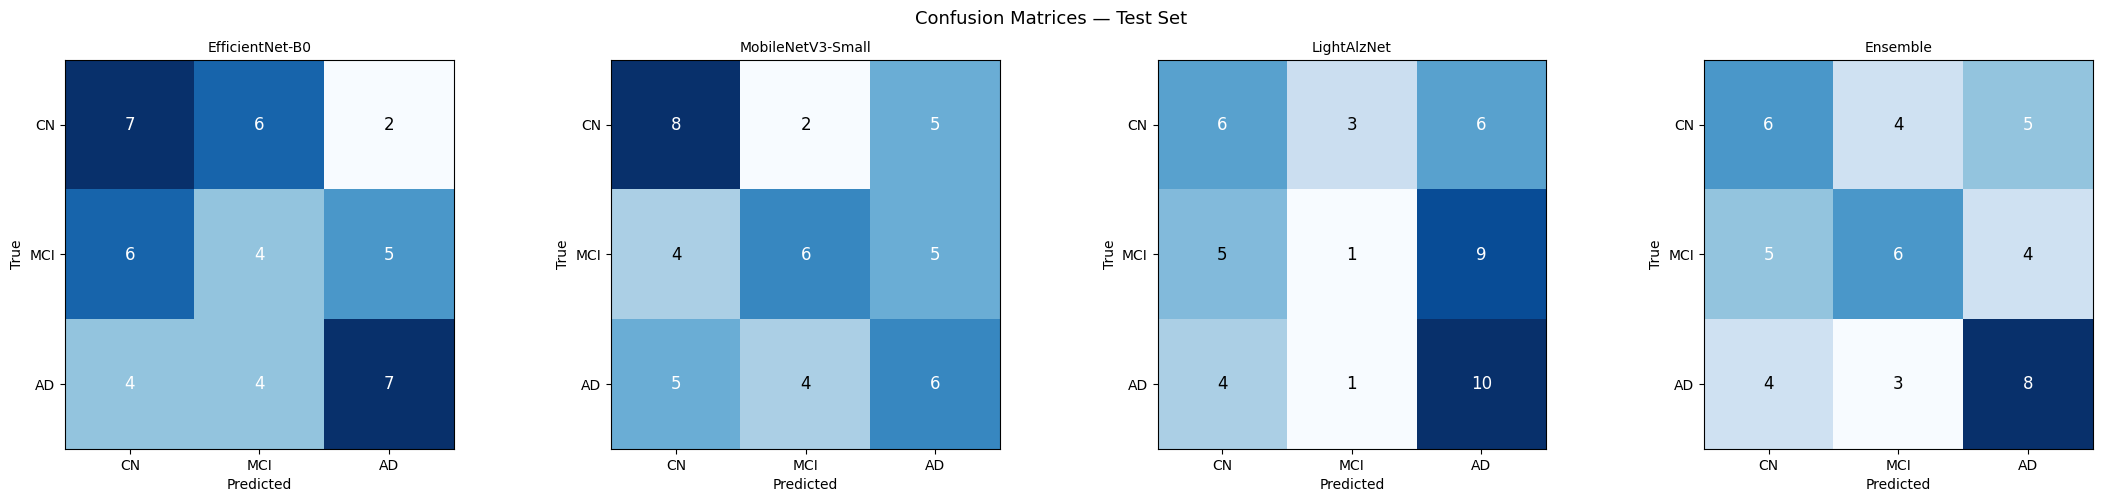

✓ confusion_matrices.png


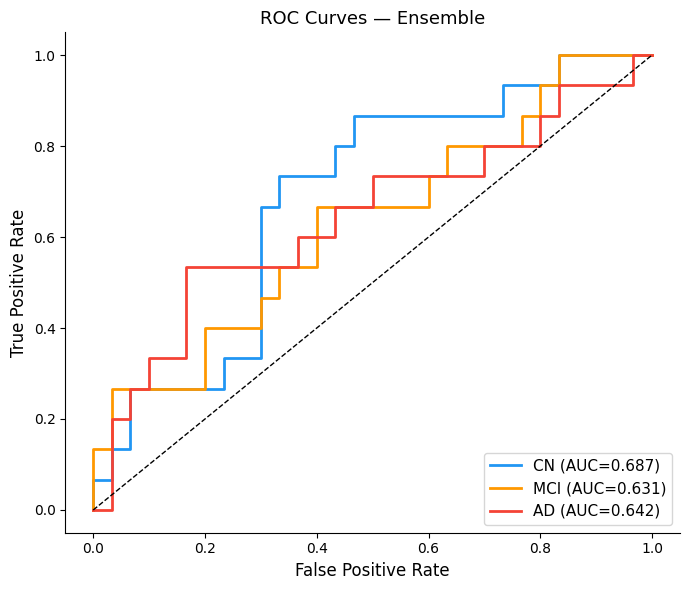

✓ roc_curves.png


In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

LOGS_P = Path('/content/drive/MyDrive/alzheimer_thesis/logs')
CLASS_NAMES = ['CN','MCI','AD']

fig,axes=plt.subplots(1,4,figsize=(22,5)); fig.suptitle('Confusion Matrices — Test Set',fontsize=13)
all_preds_cam={}
for ax,(name,model) in zip(axes[:3],models_dict.items()):
    probs,labs=get_probs(model,test_loader); preds=probs.argmax(1)
    all_preds_cam[name]=(probs,preds,labs)
    cm=confusion_matrix(labs,preds)
    ax.imshow(cm,cmap='Blues'); ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(CLASS_NAMES); ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(name,fontsize=10)
    for i in range(3):
        for j in range(3):
            ax.text(j,i,str(cm[i,j]),ha='center',va='center',fontsize=12,
                    color='white' if cm[i,j]>cm.max()/2 else 'black')
cm_ens=confusion_matrix(labels,ens_preds); ax=axes[3]; ax.imshow(cm_ens,cmap='Blues')
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(CLASS_NAMES); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title('Ensemble',fontsize=10)
for i in range(3):
    for j in range(3):
        ax.text(j,i,str(cm_ens[i,j]),ha='center',va='center',fontsize=12,
                color='white' if cm_ens[i,j]>cm_ens.max()/2 else 'black')
plt.tight_layout()
plt.savefig(str(LOGS_P/'confusion_matrices.png'),dpi=150,bbox_inches='tight')
plt.show(); print('✓ confusion_matrices.png')

fig,ax=plt.subplots(figsize=(7,6)); y_bin=label_binarize(labels,classes=[0,1,2])
for i,(cls,color) in enumerate(zip(CLASS_NAMES,['#2196F3','#FF9800','#F44336'])):
    fpr,tpr,_=roc_curve(y_bin[:,i],ens_probs[:,i])
    ax.plot(fpr,tpr,color=color,lw=2,label=f'{cls} (AUC={auc(fpr,tpr):.3f})')
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlabel('False Positive Rate',fontsize=12); ax.set_ylabel('True Positive Rate',fontsize=12)
ax.set_title('ROC Curves — Ensemble',fontsize=13)
ax.legend(loc='lower right',fontsize=11); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(str(LOGS_P/'roc_curves.png'),dpi=150,bbox_inches='tight')
plt.show(); print('✓ roc_curves.png')


---
## D — Grad-CAM (All 3 Models)

In [10]:
# ==========================================
# SECTION D — Grad-CAM (All 3 Models) BULLETPROOF
# ==========================================
import torch, numpy as np, matplotlib.pyplot as plt
import nibabel as nib
from PIL import Image as PILImage
from pathlib import Path
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BASE        = Path('/content/drive/MyDrive/alzheimer_thesis')
GRAD        = BASE / 'gradcam'
CKPT        = BASE / 'checkpoints'
CLASS_NAMES = ['CN', 'MCI', 'AD']
GRAD.mkdir(parents=True, exist_ok=True)

# 1. Self-contained extractor (prevents NameError)
def extract_25d(nifti_path, size=224):
    vol = nib.load(str(nifti_path)).get_fdata().astype(np.float32)
    if vol.ndim == 4: vol = vol[..., 0]
    z, mid = vol.shape[2], vol.shape[2] // 2
    slices = []
    for offset in [-1, 0, 1]:
        idx = int(np.clip(mid + offset, 0, z - 1))
        sl  = vol[:, :, idx]
        sl  = np.array(PILImage.fromarray(sl).resize((size, size), PILImage.BILINEAR))
        sl  = (sl - sl.mean()) / (sl.std() + 1e-8)
        slices.append(sl.astype(np.float32))
    return np.stack(slices, axis=0)

# 2. Force gradients back ON
for model in models_dict.values():
    model.eval()
    for param in model.parameters():
        param.requires_grad = True

def make_gradcam_fn(model, target_layer):
    acts, grads = {}, {}
    fh = target_layer.register_forward_hook(lambda m,i,o: acts.update({'f':o.detach()}))
    bh = target_layer.register_full_backward_hook(lambda m,gi,go: grads.update({'g':go[0].detach()}))

    def run(tensor, class_idx):
        model.zero_grad()
        # CRITICAL FIX: Force the input tensor to require gradients to guarantee the hook fires
        img_tensor = tensor.unsqueeze(0).to(DEVICE)
        img_tensor.requires_grad_(True)

        out = model(img_tensor)
        out[0, class_idx].backward()

        if 'g' not in grads:
            print("  [Warning] Gradient hook failed. Returning blank overlay.")
            return np.zeros((224, 224, 3))

        w   = grads['g'][0].mean(dim=(1,2))
        cam = torch.relu((w[:,None,None] * acts['f'][0]).sum(0)).cpu().numpy()
        cam -= cam.min()
        if cam.max() > 0: cam /= cam.max()

        cam_pil = PILImage.fromarray((cam*255).astype(np.uint8)).resize((224,224), PILImage.BILINEAR)
        return plt.cm.jet(np.array(cam_pil)/255.0)[:,:,:3]

    return run, fh, bh

def get_target_layer(model, name):
    # CRITICAL FIX: Target the specific Conv2d layers, avoiding PyTorch Sequential block bugs
    if name == 'EfficientNet-B0':    return model.features[-1][0]
    if name == 'MobileNetV3-Small':  return model.features[-1][0]
    if name == 'LightAlzNet':        return model.body[-1].block[0]

test_manifest = pd.read_csv(BASE/'data'/'manifests'/'test.csv')
N = 5

for model_name, model in models_dict.items():
    print(f'Generating Grad-CAM for {model_name}...')
    layer = get_target_layer(model, model_name)
    gcam, fh, bh = make_gradcam_fn(model, layer)
    safe = model_name.replace('-','').replace(' ','_')

    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        subset = test_manifest[test_manifest['label']==cls_idx]
        rows = subset.sample(n=min(N, len(subset)), random_state=42)

        fig, axes = plt.subplots(N, 2, figsize=(6, N*3))
        fig.suptitle(f'Grad-CAM | {model_name} | {cls_name}', fontsize=12)

        for row_i, (_, s) in enumerate(rows.iterrows()):
            arr    = extract_25d(s['path'])
            tensor = torch.from_numpy(arr)
            cam    = gcam(tensor, cls_idx)

            mid    = arr[1]
            disp   = (mid - mid.min()) / (mid.max() - mid.min() + 1e-8)
            overlay = np.clip(0.5*np.stack([disp]*3,axis=2) + 0.5*cam, 0, 1)

            axes[row_i][0].imshow(disp, cmap='gray')
            axes[row_i][0].set_title('Input MRI', fontsize=8); axes[row_i][0].axis('off')
            axes[row_i][1].imshow(overlay)
            axes[row_i][1].set_title('Grad-CAM overlay', fontsize=8); axes[row_i][1].axis('off')

        plt.tight_layout()
        out = GRAD / f'gradcam_{safe}_{cls_name}.png'
        plt.savefig(str(out), dpi=150, bbox_inches='tight'); plt.close()
        print(f'  ✓ {out.name}')

    fh.remove(); bh.remove()

print('\n✓ All Grad-CAM figures successfully saved to gradcam/!')

Generating Grad-CAM for EfficientNet-B0...
  ✓ gradcam_EfficientNetB0_CN.png
  ✓ gradcam_EfficientNetB0_MCI.png
  ✓ gradcam_EfficientNetB0_AD.png
Generating Grad-CAM for MobileNetV3-Small...
  ✓ gradcam_MobileNetV3Small_CN.png
  ✓ gradcam_MobileNetV3Small_MCI.png
  ✓ gradcam_MobileNetV3Small_AD.png
Generating Grad-CAM for LightAlzNet...
  ✓ gradcam_LightAlzNet_CN.png
  ✓ gradcam_LightAlzNet_MCI.png
  ✓ gradcam_LightAlzNet_AD.png

✓ All Grad-CAM figures successfully saved to gradcam/!


---
## E — Training Curves

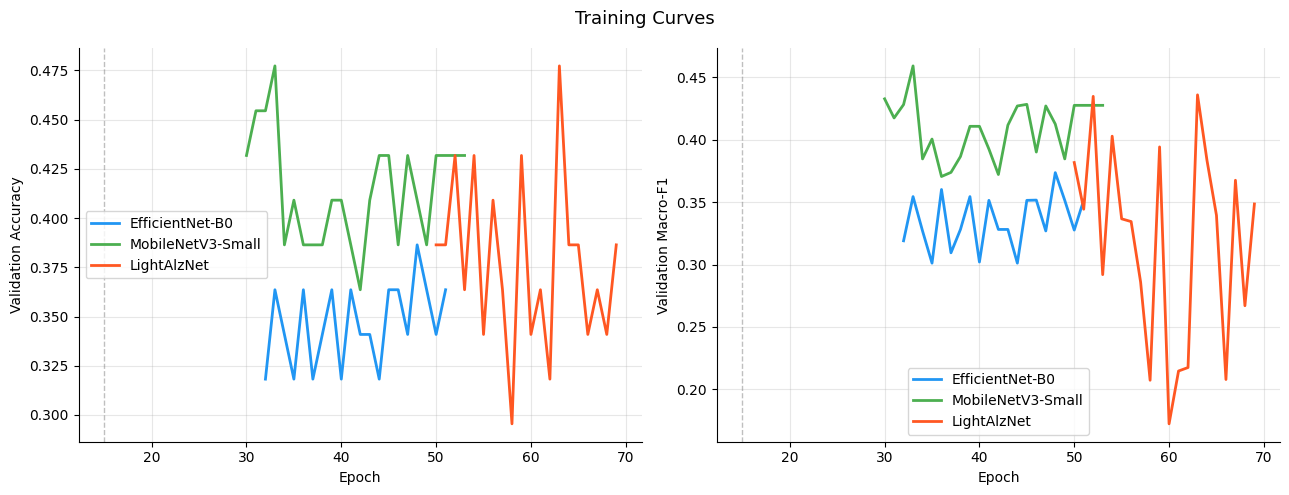

✓ training_curves.png


In [11]:
fig,axes=plt.subplots(1,2,figsize=(13,5)); fig.suptitle('Training Curves',fontsize=13)
for (key,label),color in zip({'efficientnet':'EfficientNet-B0','mobilenet':'MobileNetV3-Small',
                               'lightalznet':'LightAlzNet'}.items(),['#2196F3','#4CAF50','#FF5722']):
    hp=LOGS/f'{key}_history.json'
    if not hp.exists(): continue
    h=json.loads(hp.read_text()); ep=[e['epoch'] for e in h]
    axes[0].plot(ep,[e['val_acc'] for e in h],color=color,label=label,lw=2)
    axes[1].plot(ep,[e['val_f1'] for e in h],color=color,label=label,lw=2)
for ax,yl in zip(axes,['Validation Accuracy','Validation Macro-F1']):
    ax.set_xlabel('Epoch'); ax.set_ylabel(yl); ax.legend(fontsize=10)
    ax.grid(alpha=0.3); ax.spines[['top','right']].set_visible(False)
    ax.axvline(x=15,color='gray',linestyle='--',alpha=0.5,lw=1)
plt.tight_layout()
plt.savefig(str(LOGS/'training_curves.png'),dpi=150,bbox_inches='tight')
plt.show(); print('✓ training_curves.png')


---
## F — INT8 Quantization

In [12]:
def measure_ms(model,n=50):
    model.eval(); dummy=torch.randn(1,3,224,224)
    with torch.no_grad():
        for _ in range(5): model(dummy)
    t0=time.perf_counter()
    with torch.no_grad():
        for _ in range(n): model(dummy)
    return round((time.perf_counter()-t0)/n*1000,2)

def size_mb(model,tmp='/tmp/_q.pth'):
    torch.save(model.state_dict(),tmp); s=os.path.getsize(tmp)/1e6; os.remove(tmp); return round(s,2)

def eval_cpu(model,loader):
    model.eval(); preds,labs=[],[]
    with torch.no_grad():
        for x,y in loader:
            preds.extend(model(x).argmax(1).numpy()); labs.extend(y.numpy())
    preds,labs=np.array(preds),np.array(labs)
    return {'acc':round(float((preds==labs).mean()),4),
            'f1':round(float(f1_score(labs,preds,average='macro',zero_division=0)),4)}

print('INT8 Quantization...\n'); quant_results={}
for dname,(cname,builder) in [('EfficientNet-B0',('efficientnet',build_efficientnet)),
                                ('MobileNetV3-Small',('mobilenet',build_mobilenet)),
                                ('LightAlzNet',('lightalznet',LightAlzNet))]:
    m32=builder()
    ck=torch.load(CKPT/f'{cname}_best.pth',map_location='cpu',weights_only=False)
    m32.load_state_dict(ck['model']); m32.eval()
    m8=torch.quantization.quantize_dynamic(m32,{nn.Linear,nn.Conv2d},dtype=torch.qint8)
    e32=eval_cpu(m32,test_loader); e8=eval_cpu(m8,test_loader)
    s32=size_mb(m32); s8=size_mb(m8); t32=measure_ms(m32); t8=measure_ms(m8)
    red=round((1-s8/s32)*100,1)
    quant_results[dname]={'fp32_mb':s32,'int8_mb':s8,'reduction_pct':red,
                           'fp32_ms':t32,'int8_ms':t8,'fp32_f1':e32['f1'],'int8_f1':e8['f1']}
    torch.save(m8.state_dict(),str(COMP/f'{cname}_int8.pth'))
    print(f'  {dname}: {s32}MB→{s8}MB ({red}%) | {t32}ms→{t8}ms | F1 {e32["f1"]:.4f}→{e8["f1"]:.4f}')

print('\n'+'='*72)
print(f'{"Model":<22} {"FP32MB":>7} {"INT8MB":>7} {"Reduc%":>8} {"FP32ms":>7} {"INT8ms":>7} {"FP32F1":>8} {"INT8F1":>8}')
print('-'*72)
for n,r in quant_results.items():
    print(f'{n:<22} {r["fp32_mb"]:>7.1f} {r["int8_mb"]:>7.1f} {r["reduction_pct"]:>7.1f}% {r["fp32_ms"]:>7.1f} {r["int8_ms"]:>7.1f} {r["fp32_f1"]:>8.4f} {r["int8_f1"]:>8.4f}')
print('='*72)
(COMP/'quantization_results.json').write_text(json.dumps(quant_results,indent=2))
print('✓ Saved')


INT8 Quantization...

  EfficientNet-B0: 16.96MB→16.47MB (2.9%) | 58.88ms→46.66ms | F1 0.3987→0.3987
  MobileNetV3-Small: 6.45MB→4.49MB (30.4%) | 10.31ms→10.64ms | F1 0.4438→0.4438
  LightAlzNet: 2.56MB→2.01MB (21.5%) | 9.26ms→11.09ms | F1 0.3333→0.3333

Model                   FP32MB  INT8MB   Reduc%  FP32ms  INT8ms   FP32F1   INT8F1
------------------------------------------------------------------------
EfficientNet-B0           17.0    16.5     2.9%    58.9    46.7   0.3987   0.3987
MobileNetV3-Small          6.5     4.5    30.4%    10.3    10.6   0.4438   0.4438
LightAlzNet                2.6     2.0    21.5%     9.3    11.1   0.3333   0.3333
✓ Saved


---
## G — L1 Pruning (LightAlzNet)

In [13]:
import torch.nn.utils.prune as prune_utils, copy

light_orig=LightAlzNet()
ck=torch.load(CKPT/'lightalznet_best.pth',map_location='cpu',weights_only=False)
light_orig.load_state_dict(ck['model'])

def apply_pruning(model,amount):
    m=copy.deepcopy(model)
    for _,mod in m.named_modules():
        if isinstance(mod,nn.Conv2d):
            prune_utils.l1_unstructured(mod,name='weight',amount=amount)
            prune_utils.remove(mod,'weight')
    return m

pruning_results={}
for amount,label in [(0.0,'No pruning'),(0.20,'20% pruning'),(0.40,'40% pruning')]:
    m=copy.deepcopy(light_orig) if amount==0.0 else apply_pruning(light_orig,amount)
    m.to(DEVICE).eval()
    total=sum(p.numel() for p in m.parameters())
    nz=sum(p.nonzero().size(0) for p in m.parameters())
    sparsity=round((1-nz/total)*100,1)
    preds,labs=[],[]
    with torch.no_grad():
        for x,y in test_loader:
            preds.extend(m(x.to(DEVICE)).argmax(1).cpu().numpy()); labs.extend(y.numpy())
    preds,labs=np.array(preds),np.array(labs)
    acc=round(float((preds==labs).mean()),4)
    f1v=round(float(f1_score(labs,preds,average='macro',zero_division=0)),4)
    mb=size_mb(m.cpu()); ms=measure_ms(m.cpu())
    pruning_results[label]={'sparsity_pct':sparsity,'acc':acc,'macro_f1':f1v,'mb':mb,'ms':ms}
    torch.save(m.state_dict(),str(COMP/f'lightalznet_pruned_{int(amount*100)}.pth'))
    print(f'  {label:<18} sparsity={sparsity}%  acc={acc:.4f}  F1={f1v:.4f}  {mb}MB  {ms}ms')

print('\n'+'='*60)
print(f'{"Config":<20} {"Sparsity":>9} {"Acc":>7} {"F1":>8} {"MB":>6} {"ms":>6}')
print('-'*60)
for lbl,r in pruning_results.items():
    print(f'{lbl:<20} {r["sparsity_pct"]:>8.1f}% {r["acc"]:>7.4f} {r["macro_f1"]:>8.4f} {r["mb"]:>6.1f} {r["ms"]:>6.1f}')
print('='*60)
(COMP/'pruning_results.json').write_text(json.dumps(pruning_results,indent=2))
print('✓ Saved')


  No pruning         sparsity=0.0%  acc=0.3778  F1=0.3333  2.56MB  9.66ms
  20% pruning        sparsity=13.9%  acc=0.3111  F1=0.2545  2.56MB  13.45ms
  40% pruning        sparsity=27.9%  acc=0.5333  F1=0.5291  2.56MB  9.68ms

Config                Sparsity     Acc       F1     MB     ms
------------------------------------------------------------
No pruning                0.0%  0.3778   0.3333    2.6    9.7
20% pruning              13.9%  0.3111   0.2545    2.6   13.4
40% pruning              27.9%  0.5333   0.5291    2.6    9.7
✓ Saved


---
## H — Knowledge Distillation

In [14]:
teacher=build_efficientnet()
ck=torch.load(CKPT/'efficientnet_best.pth',map_location=DEVICE,weights_only=False)
teacher.load_state_dict(ck['model']); teacher.to(DEVICE).eval()
print(f'✓ Teacher: EfficientNet-B0 (val F1={ck["best_f1"]:.4f})')

student=LightAlzNet(num_classes=3).to(DEVICE)

class KDLoss(nn.Module):
    def __init__(self,T=4.0,alpha=0.7):
        super().__init__(); self.T,self.alpha=T,alpha
    def forward(self,s,t,y):
        kd=F.kl_div(F.log_softmax(s/self.T,dim=1),F.softmax(t/self.T,dim=1),
                    reduction='batchmean')*(self.T**2)
        return self.alpha*F.cross_entropy(s,y)+(1-self.alpha)*kd

kd_crit=KDLoss(); opt=AdamW(student.parameters(),lr=5e-5,weight_decay=5e-2)
sched=CosineAnnealingLR(opt,T_max=40,eta_min=1e-6)
best_f1,no_imp=0.0,0; kd_ckpt=COMP/'lightalznet_kd_best.pth'
print('KD training (40 epochs)\n'); t0=time.time()

for epoch in range(40):
    student.train(); teacher.eval(); tl,cor,tot=0.0,0,0
    for x,y in train_loader:
        x,y=x.to(DEVICE),y.to(DEVICE); opt.zero_grad()
        with torch.no_grad(): t_out=teacher(x)
        s_out=student(x); loss=kd_crit(s_out,t_out,y)
        loss.backward(); torch.nn.utils.clip_grad_norm_(student.parameters(),1.0); opt.step()
        tl+=loss.item()*x.size(0); cor+=(s_out.argmax(1)==y).sum().item(); tot+=x.size(0)
    sched.step()
    student.eval(); vp,vl=[],[]
    with torch.no_grad():
        for x,y in val_loader:
            vp.extend(student(x.to(DEVICE)).argmax(1).cpu().numpy()); vl.extend(y.numpy())
    vf1=f1_score(vl,vp,average='macro',zero_division=0)
    vacc=(np.array(vp)==np.array(vl)).mean()
    print(f'  Ep {epoch+1:>2}/40 loss={tl/tot:.4f} val={vacc:.3f} F1={vf1:.3f} {(time.time()-t0)/60:.1f}min')
    if vf1>best_f1:
        best_f1,no_imp=vf1,0
        torch.save({'model':student.state_dict(),'best_f1':best_f1},kd_ckpt)
        print(f'  ★ Best KD F1={best_f1:.4f}')
    else:
        no_imp+=1
        if no_imp>=10: print('Early stop'); break

ck=torch.load(kd_ckpt,map_location=DEVICE,weights_only=False)
student.load_state_dict(ck['model']); student.eval()
tp,tl=[],[]
with torch.no_grad():
    for x,y in test_loader:
        tp.extend(student(x.to(DEVICE)).argmax(1).cpu().numpy()); tl.extend(y.numpy())
kd_f1=f1_score(tl,tp,average='macro',zero_division=0)
kd_acc=(np.array(tp)==np.array(tl)).mean()

orig=load_best(LightAlzNet(),'lightalznet'); op,ol=[],[]
with torch.no_grad():
    for x,y in test_loader:
        op.extend(orig(x.to(DEVICE)).argmax(1).cpu().numpy()); ol.extend(y.numpy())
orig_f1=f1_score(ol,op,average='macro',zero_division=0)
orig_acc=(np.array(op)==np.array(ol)).mean()

print('\n'+'='*56)
print(f'{"Model":<34} {"Acc":>8} {"F1":>8}')
print('-'*56)
print(f'{"LightAlzNet (no KD)":<34} {orig_acc:>8.4f} {orig_f1:>8.4f}')
print(f'{"LightAlzNet + KD":<34} {kd_acc:>8.4f} {kd_f1:>8.4f}')
print(f'{"EfficientNet-B0 (teacher)":<34} {all_results["EfficientNet-B0"]["acc"]:>8.4f} {all_results["EfficientNet-B0"]["macro_f1"]:>8.4f}')
print('='*56)
(COMP/'kd_results.json').write_text(json.dumps({'baseline_f1':float(orig_f1),'kd_f1':float(kd_f1),
    'improvement':round(float(kd_f1-orig_f1),4)},indent=2))
print('✓ Saved')


✓ Teacher: EfficientNet-B0 (val F1=0.4023)
KD training (40 epochs)

  Ep  1/40 loss=0.7808 val=0.341 F1=0.169 2.6min
  ★ Best KD F1=0.1695
  Ep  2/40 loss=0.7828 val=0.364 F1=0.282 3.9min
  ★ Best KD F1=0.2820
  Ep  3/40 loss=0.7787 val=0.341 F1=0.169 4.8min
  Ep  4/40 loss=0.7787 val=0.295 F1=0.296 5.7min
  ★ Best KD F1=0.2961
  Ep  5/40 loss=0.7784 val=0.341 F1=0.169 6.6min
  Ep  6/40 loss=0.7858 val=0.295 F1=0.155 7.4min
  Ep  7/40 loss=0.7826 val=0.341 F1=0.266 8.2min
  Ep  8/40 loss=0.7770 val=0.409 F1=0.353 9.1min
  ★ Best KD F1=0.3526
  Ep  9/40 loss=0.7801 val=0.341 F1=0.272 9.9min
  Ep 10/40 loss=0.7755 val=0.341 F1=0.239 10.7min
  Ep 11/40 loss=0.7810 val=0.318 F1=0.161 11.6min
  Ep 12/40 loss=0.7824 val=0.318 F1=0.164 12.4min
  Ep 13/40 loss=0.7732 val=0.364 F1=0.316 13.2min
  Ep 14/40 loss=0.7817 val=0.341 F1=0.268 14.1min
  Ep 15/40 loss=0.7773 val=0.341 F1=0.273 14.9min
  Ep 16/40 loss=0.7745 val=0.364 F1=0.277 15.7min
  Ep 17/40 loss=0.7759 val=0.341 F1=0.230 16.6min
  E

---
## I — Efficiency Table

In [15]:
from torchinfo import summary

def flops_params(model):
    info=summary(model,input_size=(1,3,224,224),verbose=0)
    return info.total_params/1e6, info.total_mult_adds/1e9

def cpu_ms(model,n=100):
    model.eval().cpu(); dummy=torch.randn(1,3,224,224)
    with torch.no_grad():
        for _ in range(10): model(dummy)
    t0=time.perf_counter()
    with torch.no_grad():
        for _ in range(n): model(dummy)
    return round((time.perf_counter()-t0)/n*1000,1)

print('Efficiency metrics...\n'); rows=[]
for dname,cname,builder in [('EfficientNet-B0','efficientnet',build_efficientnet),
                              ('MobileNetV3-Small','mobilenet',build_mobilenet),
                              ('LightAlzNet','lightalznet',LightAlzNet),
                              ('LightAlzNet+KD','kd',None)]:
    try:
        m=builder() if builder else LightAlzNet()
        ckp=CKPT/f'{cname}_best.pth' if builder else COMP/'lightalznet_kd_best.pth'
        if ckp.exists():
            ck=torch.load(ckp,map_location='cpu',weights_only=False)
            m.load_state_dict(ck['model'] if 'model' in ck else ck)
        p,g=flops_params(m); mb=size_mb(m); ms=cpu_ms(m)
        rows.append((dname,p,g,mb,ms))
        print(f'  ✓ {dname:<26} {p:.2f}M  {g:.3f}GFLOPs  {mb:.1f}MB  {ms:.1f}ms')
    except Exception as e: print(f'  ⚠ {dname}: {e}')

try:
    m32=LightAlzNet()
    ck=torch.load(CKPT/'lightalznet_best.pth',map_location='cpu',weights_only=False)
    m32.load_state_dict(ck['model'])
    m8=torch.quantization.quantize_dynamic(m32,{nn.Linear,nn.Conv2d},dtype=torch.qint8)
    rows.append(('LightAlzNet INT8',float('nan'),float('nan'),size_mb(m8),cpu_ms(m8)))
    print(f'  ✓ {"LightAlzNet INT8":<26} N/A    N/A          {rows[-1][3]:.1f}MB  {rows[-1][4]:.1f}ms')
except Exception as e: print(f'  ⚠ INT8: {e}')

print('\n'+'='*70)
print('EFFICIENCY TABLE — thesis Chapter 3')
print('='*70)
print(f'{"Model":<26} {"Params":>8} {"GFLOPs":>8} {"MB":>7} {"CPU ms":>8}')
print('-'*70)
for n,p,g,mb,ms in rows:
    print(f'{n:<26} {"N/A" if p!=p else f"{p:.2f}M":>8} {"N/A" if g!=g else f"{g:.3f}":>8} {mb:>7.1f} {ms:>8.1f}')
print('='*70)


Efficiency metrics...

  ✓ EfficientNet-B0            4.17M  0.385GFLOPs  17.0MB  66.8ms
  ✓ MobileNetV3-Small          1.58M  0.056GFLOPs  6.5MB  9.7ms
  ✓ LightAlzNet                0.63M  0.091GFLOPs  2.6MB  9.0ms
  ✓ LightAlzNet+KD             0.63M  0.091GFLOPs  2.6MB  9.5ms
  ✓ LightAlzNet INT8           N/A    N/A          2.0MB  10.5ms

EFFICIENCY TABLE — thesis Chapter 3
Model                        Params   GFLOPs      MB   CPU ms
----------------------------------------------------------------------
EfficientNet-B0               4.17M    0.385    17.0     66.8
MobileNetV3-Small             1.58M    0.056     6.5      9.7
LightAlzNet                   0.63M    0.091     2.6      9.0
LightAlzNet+KD                0.63M    0.091     2.6      9.5
LightAlzNet INT8                N/A      N/A     2.0     10.5


---
## J — OASIS-1+2 Baseline Comparison

In [16]:
# Fill in your actual OASIS-1+2 numbers
oasis12={'acc':0.60,'macro_f1':0.49,'note':'3D CNN+ViT+SwinT, no N4, no stratified split'}
try:
    current=json.loads((LOGS/'test_results.json').read_text())
    ens=current.get('Ensemble',{})
    oasis3={'acc':ens.get('acc','—'),'macro_f1':ens.get('macro_f1','—')}
except: oasis3={'note':'missing'}
(LOGS/'dataset_comparison.json').write_text(json.dumps({'baseline':oasis12,'proposed':oasis3},indent=2))
print('='*60)
print(f'{"System":<38} {"Acc":>7} {"F1":>8}')
print('-'*60)
print(f'{"Baseline (OASIS-1+2)":<38} {oasis12["acc"]:>7.2f} {oasis12["macro_f1"]:>8.2f}')
try: print(f'{"Proposed (OASIS-3)":<38} {float(oasis3["acc"]):>7.4f} {float(oasis3["macro_f1"]):>8.4f}')
except: print('Run Section B first')
print('='*60)
print('\n✓ All thesis outputs saved to Drive')
print('  logs/confusion_matrices.png, roc_curves.png, training_curves.png')
print('  gradcam/*.png (9 files)')
print('  logs/test_results.json')
print('  compression/quantization_results.json, pruning_results.json, kd_results.json')


System                                     Acc       F1
------------------------------------------------------------
Baseline (OASIS-1+2)                      0.60     0.49
Proposed (OASIS-3)                      0.4444   0.4429

✓ All thesis outputs saved to Drive
  logs/confusion_matrices.png, roc_curves.png, training_curves.png
  gradcam/*.png (9 files)
  logs/test_results.json
  compression/quantization_results.json, pruning_results.json, kd_results.json
